In [16]:
import geopandas as gpd
import numpy as np

# Load GeoPackage
gdf = gpd.read_file("dallas_modeling_final.gpkg")

#variable to test
variable = "distance_to_nearest_grocery"

# Keep only valid, nonmissing observations
gdf = gdf[gdf.geometry.notna() & gdf[variable].notna()].copy()
gdf = gdf.reset_index(drop=True)

# Convert variable to numeric
gdf[variable] = gdf[variable].astype(float)

In [17]:
gdf.columns.tolist()

['COUNTY',
 'GEOID',
 'tract',
 'walking_ind',
 'walkind_inv_perc',
 'total_pop',
 'total_pop_moe',
 'below_200_fed_poverty_percentage',
 'no_hs_diploma',
 'uninsured',
 'E_CHD',
 'E_DIABETES',
 'E_AFAM',
 'E_ASIAN',
 'E_HISP',
 'median_age',
 'ALAND',
 'AWATER',
 'distance_to_nearest_grocery',
 'distance_to_nearest_fm',
 'distance_to_nearest_uf',
 'median_income',
 'pct_no_vehicle',
 'geometry']

In [18]:
gdf["geometry"] = gdf.geometry.make_valid()

In [19]:
#Queen-continguity weights
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

#neighbors
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

In [20]:
#row-standardize weights- each neighbor sum to 1
row_sums = W.sum(axis=1)

W_standardized = np.divide(
    W,
    row_sums[:, None],
    out=np.zeros_like(W),
    where=row_sums[:, None] != 0
)

In [21]:
#calculate global moran's I
x = gdf[variable].to_numpy()

x_mean = x.mean()
z = x - x_mean

n = len(x)
S0 = W_standardized.sum()

numerator = np.sum(W_standardized * np.outer(z, z))
denominator = np.sum(z ** 2)

morans_I = (n / S0) * (numerator / denominator)

expected_I = -1 / (n - 1)

print("Global Moran's I:", morans_I)
print("Expected I under spatial randomness:", expected_I)

Global Moran's I: 0.43578378457248584
Expected I under spatial randomness: -0.0014970059880239522


Interpretation:

Moran’s I above the expected value suggests positive spatial clustering.
Moran’s I below the expected value suggests spatial dispersion.
Moran’s I near the expected value suggests little spatial autocorrelation.

In [22]:
#permutation p-value 
rng = np.random.default_rng(42)

n_permutations = 999
permuted_I = np.empty(n_permutations)

for p in range(n_permutations):
    shuffled_z = rng.permutation(z)

    permuted_numerator = np.sum(
        W_standardized * np.outer(shuffled_z, shuffled_z)
    )

    permuted_I[p] = (
        (n / S0)
        * (permuted_numerator / denominator)
    )

# Two-sided pseudo p-value
extreme_count = np.sum(
    np.abs(permuted_I - expected_I)
    >= np.abs(morans_I - expected_I)
)

p_value = (extreme_count + 1) / (n_permutations + 1)

print("Permutation p-value:", p_value)

Permutation p-value: 0.001


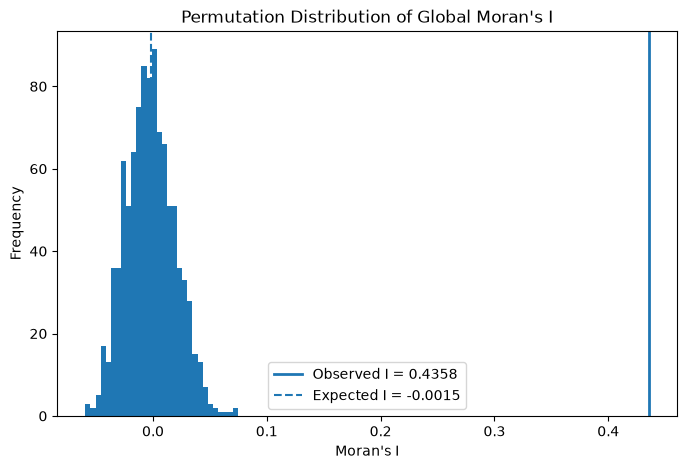

In [23]:
#permutation-distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(permuted_I, bins=30)
plt.axvline(morans_I, linewidth=2, label=f"Observed I = {morans_I:.4f}")
plt.axvline(expected_I, linestyle="--", label=f"Expected I = {expected_I:.4f}")
plt.xlabel("Moran's I")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Global Moran's I")
plt.legend()
plt.show()

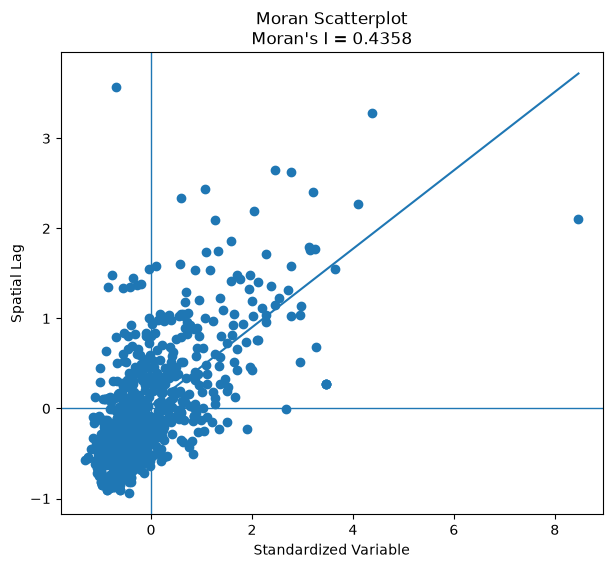

In [24]:
#moran scatterplot
# Standardize the variable
z_standardized = (x - x.mean()) / x.std(ddof=0)

# Spatial lag
spatial_lag = W_standardized @ z_standardized

plt.figure(figsize=(7, 6))
plt.scatter(z_standardized, spatial_lag)

# Regression line
slope, intercept = np.polyfit(z_standardized, spatial_lag, 1)
x_line = np.linspace(z_standardized.min(), z_standardized.max(), 100)

plt.plot(
    x_line,
    intercept + slope * x_line
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Standardized Variable")
plt.ylabel("Spatial Lag")
plt.title(f"Moran Scatterplot\nMoran's I = {morans_I:.4f}")
plt.show()